In [109]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from PCA import pca

In [110]:
df = pd.read_csv("mushrooms.csv")
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [111]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### checking for missing values or duplicates

In [112]:
print(f"nulls per column:\n{df.isnull().sum()}")
print(f"number of duplicates: {df.duplicated().sum()}")

nulls per column:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64
number of duplicates: 0


### splitting the data

In [113]:
X = df.drop(columns=["class"])
y = df["class"]
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
trainning_data = pd.concat([Xtrain, ytrain], axis=1)

### calculating the priors

In [114]:
class_counts = ytrain.value_counts()
print(f"total samples: {len(ytrain)}")
print(class_counts)
priors = class_counts / len(ytrain)
priors = priors.to_dict()
print(f"priors:\n{priors}")

total samples: 6499
class
e    3365
p    3134
Name: count, dtype: int64
priors:
{'e': 0.5177719649176796, 'p': 0.48222803508232037}


### calculating the likelihoods

In [115]:
likelihoods = {"e": {}, "p": {}}
class_e = trainning_data[trainning_data["class"] == "e"]
class_p = trainning_data[trainning_data["class"] == "p"]
features = np.array(Xtrain.columns)
for column in features:
    likelihoods["e"][column] = (class_e[column].value_counts() / len(class_e)).to_dict()
    likelihoods["p"][column] = (class_p[column].value_counts() / len(class_p)).to_dict()
print(f"likelihoods:\n{likelihoods}")

likelihoods:
{'e': {'cap-shape': {'x': 0.4710252600297177, 'f': 0.3708766716196137, 'b': 0.09301634472511144, 'k': 0.05705794947994056, 's': 0.008023774145616641}, 'cap-surface': {'f': 0.3696879643387816, 'y': 0.3589895988112927, 's': 0.2713224368499257}, 'cap-color': {'n': 0.2962852897473997, 'g': 0.2436849925705795, 'w': 0.17473997028231797, 'e': 0.14829123328380386, 'y': 0.09361069836552749, 'p': 0.014561664190193165, 'b': 0.013075780089153046, 'c': 0.008023774145616641, 'u': 0.004160475482912333, 'r': 0.003566121842496285}, 'bruises': {'t': 0.6552748885586924, 'f': 0.3447251114413076}, 'odor': {'n': 0.8136701337295691, 'a': 0.0950965824665676, 'l': 0.0912332838038633}, 'gill-attachment': {'f': 0.9548291233283804, 'a': 0.04517087667161961}, 'gill-spacing': {'c': 0.7161961367013373, 'w': 0.2838038632986627}, 'gill-size': {'b': 0.9364041604754829, 'n': 0.06359583952451708}, 'gill-color': {'w': 0.23298662704309064, 'n': 0.22585438335809807, 'p': 0.1976225854383358, 'u': 0.1054977711738

### generating predictions

In [116]:
classes = np.array(y.unique())
class_e_prob = []
class_p_prob = []
for index, row in Xtest.iterrows():
    pred_e = priors["e"]
    pred_p = priors["p"]
    for col, feature in zip(row, features):
        pred_e *= likelihoods["e"][feature].get(col, 1e-9)
        pred_p *= likelihoods["p"][feature].get(col, 1e-9)
    class_e_prob.append(pred_e)
    class_p_prob.append(pred_p)

### making the classifier decsision

In [117]:
predictions = []
for prob_e, prob_p in zip(class_e_prob, class_p_prob):
    if(prob_e > prob_p):
        predictions.append("e")
    else: 
        predictions.append("p")
print(predictions)

['e', 'p', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'e', 'e', 'e', 'e', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'p', 'e', 'p', 'e', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'p', 'e', 'e', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'p', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'e', 'e', 'e', 'e', 'e', 'e', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'e', 'e', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'e', 'p', 'e', 'e', 'p', 'p', 'e', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'e', 'e',

### evaluating the model

Accuracy Score: 0.9963076923076923
Confusion Matrix:
[[837   6]
 [  0 782]]


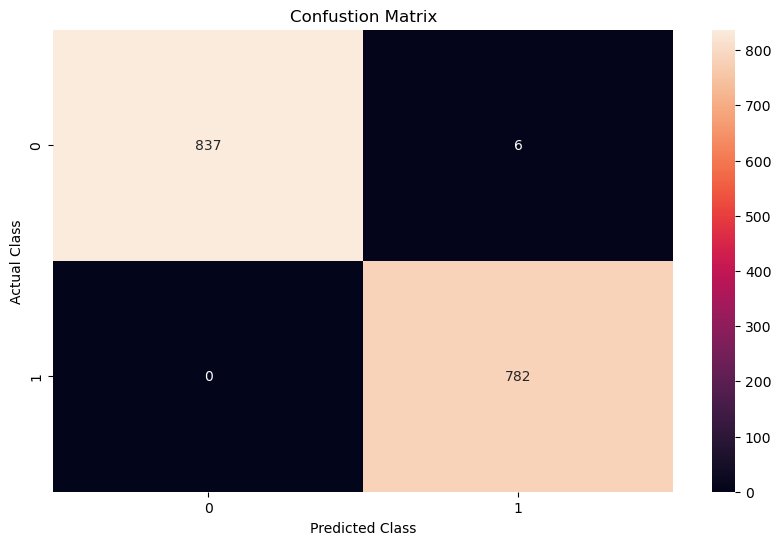

In [118]:
accuracy = accuracy_score(ytest, predictions)
confusionMatrix = confusion_matrix(ytest, predictions)
print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{confusionMatrix}")
plt.figure(figsize=(10, 6))
sns.heatmap(confusionMatrix, annot= True, fmt= "d")
plt.title("Confustion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [119]:
classificationReport = classification_report(ytest, predictions)
print(classificationReport)

              precision    recall  f1-score   support

           e       1.00      0.99      1.00       843
           p       0.99      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



# feature selection model

### encoding the features

In [120]:
one_encoder = OneHotEncoder()
lable_encoder = LabelEncoder()
X_encoded = one_encoder.fit_transform(X)
y_encoded = lable_encoder.fit_transform(y)
X_encoded = pd.DataFrame(X_encoded.toarray(), columns=one_encoder.get_feature_names_out(X.columns))
y_encoded = pd.Series(y_encoded)

### feature selection

In [121]:
selector = SelectKBest(score_func=chi2, k=50)
X_selected = selector.fit_transform(X_encoded, y_encoded)
selected_features = X_encoded.columns[selector.get_support()]
X_selected = pd.DataFrame(X_selected, columns=selected_features)
Xtrain_selected, Xtest_selected, ytrain_selected, ytest_selected = train_test_split(X_selected, y_encoded, test_size=0.2, random_state=42)

### claculating priors and likelihoods

In [122]:
priors_selected = ytrain_selected.value_counts() / len(ytrain_selected)
priors_selected = priors_selected.to_dict()
likelihoods_selected = {"e": {}, "p": {}}
trainning_data_selected = pd.concat([Xtrain_selected, ytrain_selected], axis=1)
class_e_selected = trainning_data_selected[trainning_data_selected[0] == 0]
class_p_selected = trainning_data_selected[trainning_data_selected[0] == 1]
features_selected = np.array(Xtrain_selected.columns)
for column in features_selected:
    likelihoods_selected["e"][column] = (class_e_selected[column].value_counts() / len(class_e_selected)).to_dict()
    likelihoods_selected["p"][column] = (class_p_selected[column].value_counts() / len(class_p_selected)).to_dict()
print(likelihoods_selected)

{'e': {'cap-shape_b': {0.0: 0.9069836552748886, 1.0: 0.09301634472511144}, 'cap-shape_k': {0.0: 0.9429420505200594, 1.0: 0.05705794947994056}, 'cap-surface_f': {0.0: 0.6303120356612184, 1.0: 0.3696879643387816}, 'bruises_f': {0.0: 0.6552748885586924, 1.0: 0.3447251114413076}, 'bruises_t': {1.0: 0.6552748885586924, 0.0: 0.3447251114413076}, 'odor_a': {0.0: 0.9049034175334324, 1.0: 0.0950965824665676}, 'odor_c': {0.0: 1.0}, 'odor_f': {0.0: 1.0}, 'odor_l': {0.0: 0.9087667161961367, 1.0: 0.0912332838038633}, 'odor_n': {1.0: 0.8136701337295691, 0.0: 0.1863298662704309}, 'odor_p': {0.0: 1.0}, 'odor_s': {0.0: 1.0}, 'odor_y': {0.0: 1.0}, 'gill-spacing_w': {0.0: 0.7161961367013373, 1.0: 0.2838038632986627}, 'gill-size_b': {1.0: 0.9364041604754829, 0.0: 0.06359583952451708}, 'gill-size_n': {0.0: 0.9364041604754829, 1.0: 0.06359583952451708}, 'gill-color_b': {0.0: 1.0}, 'gill-color_n': {0.0: 0.774145616641902, 1.0: 0.22585438335809807}, 'gill-color_u': {0.0: 0.8945022288261516, 1.0: 0.10549777117

### generating predictions

In [123]:
class_e_prob = []
class_p_prob = []
for index, row in Xtest_selected.iterrows():
    pred_e = priors_selected[0]
    pred_p = priors_selected[1]
    for col, feature in zip(row, selected_features):
        pred_e *= likelihoods_selected["e"][feature].get(col, 1e-9)
        pred_p *= likelihoods_selected["p"][feature].get(col, 1e-9)
    class_e_prob.append(pred_e)
    class_p_prob.append(pred_p)
predictions = []
for prob_e, prob_p in zip(class_e_prob, class_p_prob):
    if(prob_e > prob_p):
        predictions.append("e")
    else: 
        predictions.append("p")

print(class_e_prob)
print(class_p_prob)

[1.223756442979828e-07, 4.266097684091367e-30, 1.5073518267413827e-31, 2.084772283376314e-06, 4.266097684091367e-30, 1.5073518267413827e-31, 2.488831088310548e-16, 5.611538081600086e-43, 2.77945750059977e-06, 7.6740026942711e-05, 9.336605263690992e-06, 2.395212110783416e-06, 9.238156743350691e-09, 1.3010784885782179e-08, 1.966189741421654e-08, 2.9430135725608827e-07, 2.9374817135795894e-09, 1.6467998955690992e-30, 9.238828222996904e-07, 1.7261239435482018e-07, 8.688547560854833e-10, 1.9336068903827997e-09, 1.3395734071095867e-32, 1.2022319233146238e-06, 4.125486329525118e-16, 8.863483233383898e-10, 1.6243307327383384e-05, 7.40966773361982e-07, 7.852310406937689e-07, 7.166485466342064e-17, 2.7215083690837256e-29, 8.275589236044284e-43, 4.196620189162096e-05, 0.00010181010337811353, 3.1436071997243434e-06, 2.385707626099725e-33, 1.7568490102673722e-07, 6.810424296629427e-42, 1.3395734071095867e-32, 1.3395734071095867e-32, 1.5111839951138716e-31, 2.5908952651919827e-07, 4.5598383843127947

### evaluating the model

Accuracy Score after feature selection: 0.9772307692307692
Confusion Matrix after feature selection:
[[822  21]
 [ 16 766]]


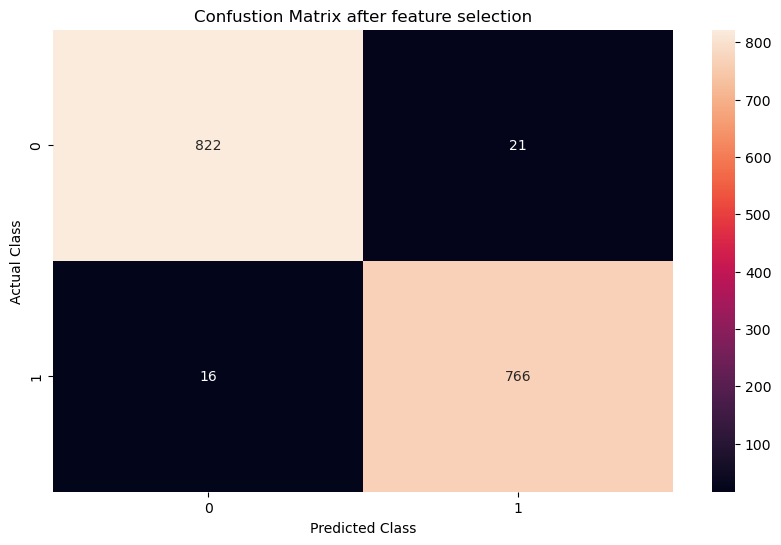

              precision    recall  f1-score   support

           e       0.98      0.98      0.98       843
           p       0.97      0.98      0.98       782

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



In [124]:
accuracy_selected = accuracy_score(ytest, predictions)
confusionMatrix_selected = confusion_matrix(ytest, predictions)
classificationReport_selected = classification_report(ytest, predictions)
print(f"Accuracy Score after feature selection: {accuracy_selected}")
print(f"Confusion Matrix after feature selection:\n{confusionMatrix_selected}")
plt.figure(figsize=(10, 6))
sns.heatmap(confusionMatrix_selected, annot= True, fmt= "d")
plt.title("Confustion Matrix after feature selection")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()
print(classificationReport_selected)

# PCA model

In [125]:
X_projected, _ = pca(X_encoded, 50)
X_projected

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.996245,0.946892,-0.802493,1.267016,-0.984733,0.202130,0.627629,0.917816,-0.168588,-0.944735,...,0.130154,0.567829,-0.005030,-0.343357,0.223000,0.242968,-0.157842,0.076907,-0.011776,-0.074885
1,-1.441733,0.164154,-1.068175,1.490404,-0.573606,0.228371,0.146374,0.156965,0.691502,0.332898,...,0.343457,0.578725,-0.223961,0.036054,0.608543,-0.170156,0.272328,0.176750,-0.312652,0.029634
2,-1.524085,0.408746,-0.853172,1.685729,-0.214971,-0.298378,0.508842,0.002269,0.422888,0.263408,...,-0.079430,-0.166932,0.073736,0.178132,-0.062718,0.253819,-0.118742,-0.027955,0.014268,-0.005264
3,-1.151800,0.675820,-0.629840,1.440281,-1.231740,0.041621,-0.327279,0.631125,-0.739247,-0.722837,...,-0.055109,0.096942,-0.021988,0.169251,-0.349796,0.201352,-0.092839,0.033699,0.022714,-0.229405
4,-0.617503,0.996143,-1.725882,-1.428404,-0.193594,0.572471,-0.251348,0.249390,0.485667,0.692119,...,-0.073844,0.470381,-0.193302,-0.423811,0.029826,-0.141083,-0.344030,0.208163,0.133344,-0.008564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,-0.126657,0.410460,-0.340034,0.899678,2.435385,0.633568,1.215993,1.603631,0.760892,-0.093985,...,0.263883,0.178362,0.214318,0.087828,0.006201,-0.190026,0.097120,0.010818,0.086299,0.008497
8120,-0.071756,0.367338,-0.137013,0.846180,1.722920,1.209726,1.369929,1.699777,0.761042,0.104757,...,0.057180,-0.006626,-0.042887,-0.104617,0.102514,0.034605,0.151551,-0.183359,0.229337,0.001679
8121,-0.287817,0.326214,-0.274664,0.673417,2.391079,-0.031419,1.357906,1.783239,0.580543,-0.139752,...,0.305308,0.164235,0.169548,0.189965,0.045462,-0.087070,0.010988,0.054766,0.055963,-0.035033
8122,1.930433,1.573163,0.115751,0.411072,-0.088299,-0.239147,-0.472670,0.349340,-0.382557,0.198084,...,0.050680,0.059472,-0.224079,0.123828,-0.064681,-0.112626,-0.019750,0.018300,-0.042694,0.097036


#### categorical NB won't work with the projected data as they becoome continuos, so we will use gaussian NB

### calculating the priors and parameters

In [126]:
Xtrain_projected, Xtest_projected, ytrain_projected, ytest_projected = train_test_split(X_projected, y, test_size=0.2, random_state=42)
trainning_data_projected = pd.concat([pd.DataFrame(Xtrain_projected), pd.Series(ytrain_projected)], axis=1)
priors_projected = ytrain_projected.value_counts() / len(ytrain_projected)
priors_projected = priors_projected.to_dict()
means = {"e": {}, "p": {}}
varinces = {"e": {}, "p": {}}
class_e_projected = trainning_data_projected[trainning_data_projected["class"] == "e"]
class_p_projected = trainning_data_projected[trainning_data_projected["class"] == "p"]
features_projected = np.array(Xtrain_projected.columns)
for column in features_projected:
    means["e"][column] = class_e_projected[column].mean()
    means["p"][column] = class_p_projected[column].mean()
    varinces["e"][column] = class_e_projected[column].var()
    varinces["p"][column] = class_p_projected[column].var()
print(means)
print(varinces)

{'e': {np.int64(0): np.float64(-1.0147242794006208), np.int64(1): np.float64(0.26535401435030215), np.int64(2): np.float64(-0.07685499230190553), np.int64(3): np.float64(-0.14409153160783103), np.int64(4): np.float64(0.21616096869795473), np.int64(5): np.float64(0.054702553368639946), np.int64(6): np.float64(-0.11973998337298059), np.int64(7): np.float64(0.018784671135488595), np.int64(8): np.float64(0.019398774612230222), np.int64(9): np.float64(0.0014891582799954834), np.int64(10): np.float64(0.02974842891640675), np.int64(11): np.float64(-0.039278888151469474), np.int64(12): np.float64(0.012249191303723723), np.int64(13): np.float64(-0.040837794739644356), np.int64(14): np.float64(0.030410583621611396), np.int64(15): np.float64(0.015111333568632371), np.int64(16): np.float64(0.034630433816158775), np.int64(17): np.float64(-0.0198302750578402), np.int64(18): np.float64(0.021965802542101672), np.int64(19): np.float64(0.013557514668024984), np.int64(20): np.float64(0.02971884784194898)

### generating predictions

In [127]:
def gaussian_likelihood(x, mean, var):
    coeff = 1.0 / np.sqrt(2.0 * np.pi * var)
    exponent = np.exp(-((x - mean) ** 2) / (2.0 * var))
    return coeff * exponent

In [128]:
class_e_prob = []
class_p_prob = []
for index, row in Xtest_projected.iterrows():
    pred_e = priors_projected["e"]
    pred_p = priors_projected["p"]
    for col, feature in zip(row, features_projected):
        pred_e *= gaussian_likelihood(col, means["e"][feature], varinces["e"][feature])
        pred_p *= gaussian_likelihood(col, means["p"][feature], varinces["p"][feature])
    class_e_prob.append(pred_e)
    class_p_prob.append(pred_p)
predictions = []
for prob_e, prob_p in zip(class_e_prob, class_p_prob):
    if(prob_e > prob_p):
        predictions.append("e")
    else: 
        predictions.append("p")
print(class_e_prob)
print(class_p_prob)

[np.float64(10568019.768551713), np.float64(0.0), np.float64(22.528621656328433), np.float64(695496122.0193298), np.float64(0.0), np.float64(0.0), np.float64(6.700078008469596), np.float64(7.195132460249749e-76), np.float64(9974650886.66523), np.float64(19312446271.645332), np.float64(17793741625.740974), np.float64(1.9875535149808302e-05), np.float64(9478.258518000219), np.float64(654451.5228774901), np.float64(137.08482007517838), np.float64(426699537.3508601), np.float64(86119.97567695919), np.float64(4.452336974372583), np.float64(26000.25423697063), np.float64(231358542.79363284), np.float64(359.4223733240802), np.float64(3.6317851383519458e-06), np.float64(0.0), np.float64(1582486063.9905827), np.float64(7285320.996923095), np.float64(7647953.990859412), np.float64(8977597752.622349), np.float64(3297358992.622504), np.float64(209326904.2156851), np.float64(36474.64120256903), np.float64(0.0), np.float64(4.84137223123944e-69), np.float64(3480059524.159109), np.float64(46204550859.

### evaluating the model

Accuracy Score after PCA: 0.9193846153846154
Confusion Matrix after PCA:
[[820  23]
 [108 674]]


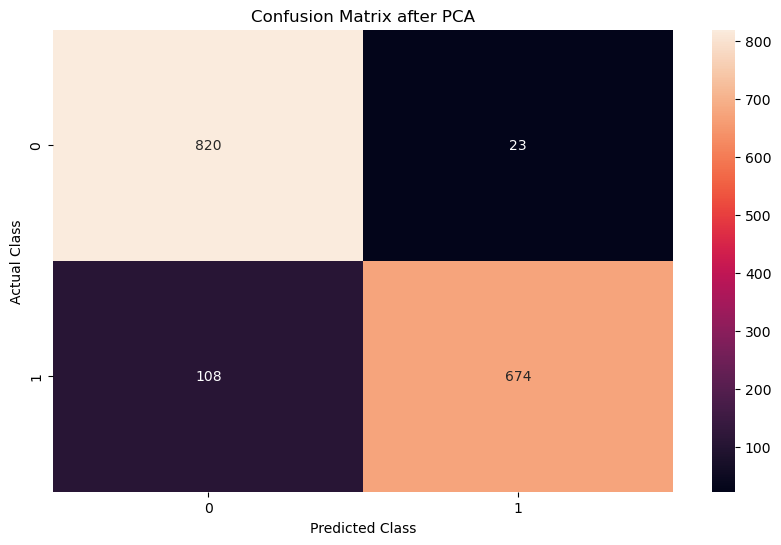

              precision    recall  f1-score   support

           e       0.88      0.97      0.93       843
           p       0.97      0.86      0.91       782

    accuracy                           0.92      1625
   macro avg       0.93      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625



In [129]:
accuracy_projected = accuracy_score(ytest, predictions)
confusionMatrix_projected = confusion_matrix(ytest, predictions)
classificationReport_projected = classification_report(ytest, predictions)
print(f"Accuracy Score after PCA: {accuracy_projected}")
print(f"Confusion Matrix after PCA:\n{confusionMatrix_projected}")
plt.figure(figsize=(10, 6))
sns.heatmap(confusionMatrix_projected, annot= True, fmt= "d")
plt.title("Confusion Matrix after PCA")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()
print(classificationReport_projected)